# Hubble fit notebook

Run the fiducial Hubble fit with the same settings as `run_hubble.xonsh`, then plot the Hubble diagram and full residual diagnostics.


## Terminal command

This is the bash command equivalent for generating the full plot set from the terminal.

```bash
NUM_CORES=30 python -m qvc.hubble.hubble_fit --resume \
    --cosmo_models Flatw0waCDM \
    --run single \
    --wrms_cut 1.2 \
    --fhost_cut 0.1 \
    --iron_frac_cut 0.001 \
    --bc_frac_cut 0.000630957344480193 \
    --variability_chi_sq_cut 10.0 \
    --speed fast \
    --spectra_fit_csv results/data/mar27g_ma21d.csv \
    --z_range 0.44 3.16 \
    --result_prefix fiducial \
    --prefix mar29_all_dev \
    --correct-sigma-uv-host \
    results/data/mar28b_all_chisq_N1w2000s200t14ch4.h5
```


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import warnings

warnings.filterwarnings("ignore")

# Set these before importing qvc.hubble.hubble_fit.
#os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
#os.environ.setdefault("NUM_CORES", "30")

In [3]:
from qvc.hubble.hubble_fit import (
    load_pantheon_data,
    make_run_tag,
    run_single,
    z_pivot_agn,
)
from qvc.hubble.hubble_plotting import (
    plot_debias_impact_diagnostics,
    plot_full_residuals,
    plot_full_residuals_rz,
    plot_hubble,
    plot_redshift_bin_residual_summary,
    plot_residuals_vs_alphaOX,
)
from qvc.hubble.hubble_utils import (
    load_agn_data,
    resolve_qvc_data_path,
    resolve_qvc_result_path,
)


CPU Num Cores: 30


In [ ]:
# Parameters mirrored from run_hubble.xonsh.
speed = "fast"
cosmo_model = "Flatw0waCDM"
run_mode = "single"

h5_file = resolve_qvc_data_path("results/data/mar28b_all_chisq_N1w2000s200t14ch4.h5")
spectra_fit_csv = [resolve_qvc_data_path("results/data/mar27g_ma21d.csv")]
prefix = f"mar29_all_{speed}"
result_prefix = "fiducial"

wrms_cut = 1.2
fhost_cut = 0.1
iron_frac_cut = 10**-3
bc_frac_cut = 10**-3.2
variability_chi_sq_cut = 10.0
z_range = (0.44, 3.16)
correct_sigma_uv_host = True

assert run_mode == "single"

In [5]:
df_pantheon, sna_logdet_cov, sna_L, sna_lower = load_pantheon_data()
agn_plot_path = f"plots/hubble/{prefix}"

df_agn, df_agn_all = load_agn_data(
    h5_file,
    populate_sdss=False,
    apply_cut=True,
    fhost_cut=fhost_cut,
    spectra_fit_csv=spectra_fit_csv,
    correct_sigma_uv_host=correct_sigma_uv_host,
    wrms_cut=wrms_cut,
    iron_frac_cut=iron_frac_cut,
    bc_frac_cut=bc_frac_cut,
    variability_chi_sq_cut=variability_chi_sq_cut,
    z_range=z_range,
    plot_path=agn_plot_path,
)

print(f"Selected AGN: {len(df_agn)}")
print(f"Pantheon+ SNe: {len(df_pantheon)}")

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).
Number of quasars loaded: 38825
Populating SDSS fields...
Populating SDSS fields: 38825
Populating spectra fit data from: ['/home/dutra/dev/qvc2/results/data/mar27g_ma21d.csv']
Loading spectra fit CSV (1/1): /home/dutra/dev/qvc2/results/data/mar27g_ma21d.csv
Length of merged DataFrame (best=True): 38825
Applied sigma_uv host correction using f_host_center: sigma_uv_corrected = sigma_uv / (1 - f_host_center)
Host sigma_uv correction sanity check: median delta=0.0102 dex, min delta=0.0000 dex
Cut on apparent_mag_2500 : 7636 objects removed
Matched 464 out of 31189 objects to CSC3 catalog.
Number of quasars with 0 < z <= 1.0: 5396
Number of quasars with z > 3: 1615
Highest redshift quasar: 4.91943087058762
Excluding 1 objects by exclusion list
Cut on tau vs sigma diagram: 1682 objects removed
Removed 0 objects with len_dropped_bands == 4

In [6]:
run_tag = make_run_tag(
    cosmo_model,
    only_sna=False,
    speed=speed,
    N=None,
    z_range=z_range,
)
plot_path = f"plots/hubble/{prefix}/{run_tag}"
resume_file = resolve_qvc_result_path(
    f"results/hubble_posteriors/{prefix}/posteriors_{run_tag}.h5"
)

fit_result = run_single(
    df_agn=df_agn,
    df_agn_all=df_agn_all,
    df_pantheon=df_pantheon,
    _sna_L=sna_L,
    _sna_Lower=sna_lower,
    _sna_LogdetCov=sna_logdet_cov,
    cosmo_model=cosmo_model,
    completeness=True,
    use_full_cov=True,
    resume=resume_file,
    only_sna=False,
    speed=speed,
    z_range=z_range,
    skip_plots=True,
    prefix=prefix,
)

flat_samples, model_labels, dm_interp, logZ, logZerr, _, age, age_err = fit_result

print(f"run_tag: {run_tag}")
print(f"plot_path: {plot_path}")
print(f"resume_file: {resume_file}")
print(f"result_prefix: {result_prefix}")
print(f"logZ = {logZ:.3f} +/- {logZerr:.3f}")
print(f"Age of the universe = {age:.3f} +/- {age_err:.3f} Gyr")

Saving plots to  plots/hubble/mar29_all_dev/Flatw0waCDM_joint_dev_all_z0p44_3p16
Completeness enabled with mock catalog file: data/nov9_mock_mag_z_moresources.h5

AGN pivot summary
--------------------------------------------------------------------
Quantity       Type                 log10 value    linear value
sigma_uv       computed mean            -0.8662          0.1361
tau_uv_rf      computed mean             2.7384        547.5652
sigma_uv       fixed pivot              -0.8662          0.1361
tau_uv_rf      fixed pivot               2.7384        547.5652
Running sampling with 9 parameters for cosmological model: Flatw0waCDM
Building 2d completeness map using mock catalog: data/nov9_mock_mag_z_moresources.h5
Smoothing counts with sigma_mag=0.2 mag (sigma_mag/dm=1.0909090909091106), sigma_z=0.2 absolute z
Checkpoint file: /home/dutra/dev/qvc2/results/hubble_posteriors/mar29_all_dev/posteriors_Flatw0waCDM_joint_dev_all_z0p44_3p16.h5
Starting Hubble Fit with 12420 AGNs and 1657 SN

Using linear-z bins: [0.32 0.52 0.72 0.92 1.12 1.32 1.52 1.72 1.92 2.12 2.32 2.52 2.72 2.92
 3.12 3.32 3.52 3.72]
Note: 0 / 12505 AGN clipped in residuals panel (> 3σ)
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42]
	mask_in: [False  True  True  True  True  True  True  True  True  True  True  True
  True  True False False]
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42]
	mask_out: [ True False False False False False False False False False False False
 False False  True  True]


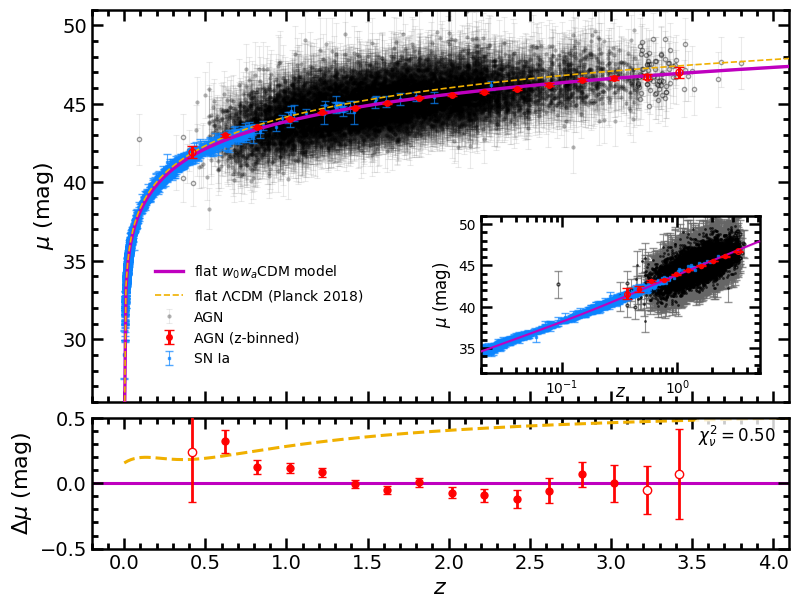

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 2.77 | object_id: 1427095 | npca_qso: N/A | SDSS: 005647.48+004251.8 | RA: 14.19787 | DEC: 0.71441 | Residual: -4.2
	z: 1.93 | object_id: 1446755 | npca_qso: N/A | SDSS: 234719.19+000357.2 | RA: 356.82997 | DEC: 0.06591 | Residual: 4.0
	z: 0.75 | object_id: 1456217 | npca_qso: N/A | SDSS: 223443.75+002116.2 | RA: 338.68233 | DEC: 0.35452 | Residual: 4.1
	z: 1.21 | object_id: 1400842 | npca_qso: N/A | SDSS: 021529.40-003116.4 | RA: 33.87252 | DEC: -0.52123 | Residual: 4.1
	z: 1.05 | object_id: 1421101 | npca_qso: N/A | SDSS: 011558.22+001046.0 | RA: 18.99260 | DEC: 0.17947 | Residual: 4.2
	z: 1.72 | object_id: 1410720 | npca_qso: N/A | SDSS: 014601.31-004033.3 | RA: 26.50549 | DEC: -0.67594 | Residual: 4.2
	z: 1.24 | object_id: 1449226 | npca_qso: N/A | SDSS: 232821.36+000428.2 | RA: 352.08904 | DEC: 0.07452 | Residual: 4.4
	z: 0.09 | object_id: 1420140 | npca_q

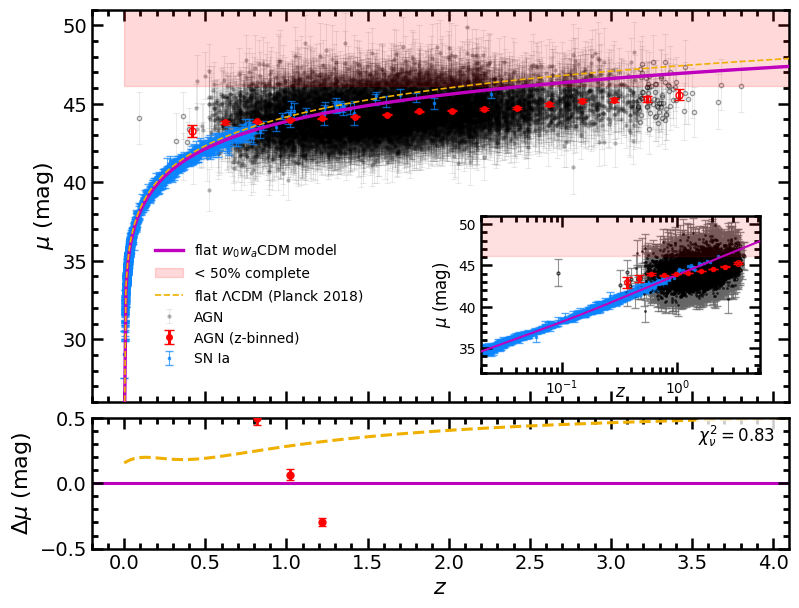

In [7]:
debiased_residuals, debiased_residuals_err, mu_pred_median, mu_pred_std, mu_pred_std_with_scatter = plot_hubble(
    flat_samples,
    df_agn,
    df_pantheon,
    cosmo_model=cosmo_model,
    z_pivot_agn=z_pivot_agn,
    plot_path=plot_path,
    show_binned_agn=True,
    show_residuals=True,
    debias=True,
    dm_interp=dm_interp,
    show=True,
    completeness=True,
    verbose=True,
    z_range=z_range,
)

biased_residuals, biased_residuals_err, _, _, _ = plot_hubble(
    flat_samples,
    df_agn,
    df_pantheon,
    cosmo_model=cosmo_model,
    z_pivot_agn=z_pivot_agn,
    plot_path=plot_path,
    show_binned_agn=True,
    show_residuals=True,
    debias=False,
    show=True,
    completeness=True,
    verbose=False,
    z_range=z_range,
)


## Residual diagnostics

These figures are saved under `plot_path` and match the residual diagnostic suite used by the pipeline when `run_single(..., skip_plots=False)`.


In [8]:
plot_full_residuals(
    df_agn,
    debiased_residuals,
    debiased_residuals_err,
    flat_samples,
    cosmo_model,
    z_pivot_agn,
    debias=True,
    dm_interp=dm_interp,
    show=False,
    plot_path=plot_path,
    z_range=z_range,
)

plot_full_residuals(
    df_agn,
    debiased_residuals,
    debiased_residuals_err,
    flat_samples,
    cosmo_model,
    z_pivot_agn,
    debias=True,
    dm_interp=dm_interp,
    show=False,
    plot_path=plot_path,
    key_y="z",
    key_color="residuals",
    z_range=z_range,
)

plot_full_residuals_rz(
    df_agn,
    debiased_residuals,
    debiased_residuals_err,
    flat_samples,
    cosmo_model,
    z_pivot_agn,
    debias=True,
    dm_interp=dm_interp,
    show=False,
    plot_path=plot_path,
    z_range=z_range,
)

plot_debias_impact_diagnostics(
    df_agn,
    biased_residuals,
    debiased_residuals,
    plot_path=plot_path,
    show=False,
)

plot_redshift_bin_residual_summary(
    df_agn,
    biased_residuals,
    biased_residuals_err,
    debiased_residuals,
    debiased_residuals_err,
    plot_path=plot_path,
    show=False,
)

plot_residuals_vs_alphaOX(
    df_agn,
    debiased_residuals,
    debiased_residuals_err,
    plot_path=plot_path,
    show=False,
)


In [9]:
import pandas as pd

summary = pd.DataFrame(
    {
        "z": df_agn["z"].to_numpy(),
        "object_id": df_agn["object_id"].astype(str).to_numpy(),
        "mu_pred": mu_pred_median,
        "mu_pred_err": mu_pred_std_with_scatter,
        "residual": debiased_residuals,
        "residual_err": debiased_residuals_err,
    }
).sort_values("z")

summary.head()


,z,object_id,mu_pred,mu_pred_err,residual,residual_err
262,0.091741,1420140,42.730459,1.649253,4.740200,1.649253
2292,0.318017,1397896,41.253208,1.757532,0.264079,1.757532
9643,0.362553,1459003,42.867072,1.465734,1.546381,1.465734
8657,0.363296,1407541,40.245869,1.493541,-1.080038,1.493541
2915,0.388394,1418021,41.185547,1.245923,-0.310728,1.245923
